**Bar chart vs histogram**

A bar chart compares different categories, while a histogram shows the distribution of numerical data.

**Boxplot**

A boxplot shows the median, quartiles, spread, and outliers of data

**Matplotlib labels:**

Use **plt.xlabel()** and **plt.ylabel() **for axis labels, **plt.title()** for the title, and **plt.legend()** for the legend.

**Heatmap:**

A heatmap is used in EDA to show relationships and correlations between variables using colors

**Pie chart:**

A pie chart is usually a bad choice for more than 4–5 categories because too many slices make the chart difficult to read and compare.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/merged_players.csv")

In [3]:
df.head()

,player_id,year,team,is_finals,games_played,kicks,marks,handballs,disposals,goals,...,debut_date,debut_age,last_date,last_age,height,weight,profile_pic,player_link,player_common_names,player_teams
0,43261,2018,Geelong Cats,False,3,17.0,9.0,21.0,38.0,3.0,...,2018-08-02,27,2020-09-05,29,200,100.0,Not available,https://afltables.com/afl/stats/players/R/Ryan...,NaN,"{Geelong Cats,St Kilda Saints}"
1,43261,2018,Geelong Cats,True,1,3.0,2.0,2.0,5.0,0.0,...,2018-08-02,27,2020-09-05,29,200,100.0,Not available,https://afltables.com/afl/stats/players/R/Ryan...,NaN,"{Geelong Cats,St Kilda Saints}"
2,43261,2019,Geelong Cats,False,1,5.0,3.0,6.0,11.0,1.0,...,2018-08-02,27,2020-09-05,29,200,100.0,Not available,https://afltables.com/afl/stats/players/R/Ryan...,NaN,"{Geelong Cats,St Kilda Saints}"
3,43261,2020,St Kilda Saints,False,1,2.0,2.0,1.0,3.0,1.0,...,2018-08-02,27,2020-09-05,29,200,100.0,Not available,https://afltables.com/afl/stats/players/R/Ryan...,NaN,"{Geelong Cats,St Kilda Saints}"
4,43262,2002,Geelong Cats,False,12,37.0,13.0,63.0,100.0,10.0,...,2002-03-30,17,2020-10-24,36,182,87.0,Not available,https://afltables.com/afl/stats/players/G/Gary...,NaN,"{Geelong Cats,Gold Coast Suns}"


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 25077
Columns: 70


In [5]:
df.isnull().sum().sort_values(ascending=False).head(10)

,0
player_common_names,24169
player_id,0
team,0
is_finals,0
games_played,0
year,0
kicks,0
marks,0
disposals,0
handballs,0


In [6]:
numeric_columns = [
    'year',
    'games_played',
    'goals',
    'disposals',
    'avg_disposals',
    'avg_goals',
    'avg_fantasy_points',
    'height',
    'weight'
]

df_clean = df.copy()

df_clean[numeric_columns] = df_clean[numeric_columns].apply(
    pd.to_numeric, errors='coerce'
)

df_clean[numeric_columns] = df_clean[numeric_columns].fillna(
    df_clean[numeric_columns].median()
)

In [7]:
df_clean[numeric_columns].isnull().sum()

,0
year,0
games_played,0
goals,0
disposals,0
avg_disposals,0
avg_goals,0
avg_fantasy_points,0
height,0
weight,0


**LINE CHART**

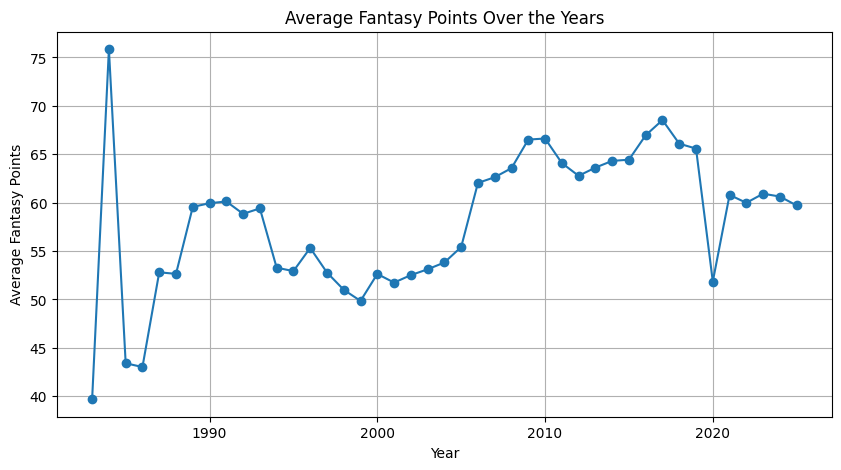

In [8]:
yearly_fantasy = df_clean.groupby('year')['avg_fantasy_points'].mean()

plt.figure(figsize=(10, 5))

plt.plot(yearly_fantasy.index, yearly_fantasy.values, marker='o')

plt.title('Average Fantasy Points Over the Years')
plt.xlabel('Year')
plt.ylabel('Average Fantasy Points')

plt.grid(True)
plt.show()

What this tells us: This chart shows how players' average fantasy performance has changed over the years.

**BAR CHART**

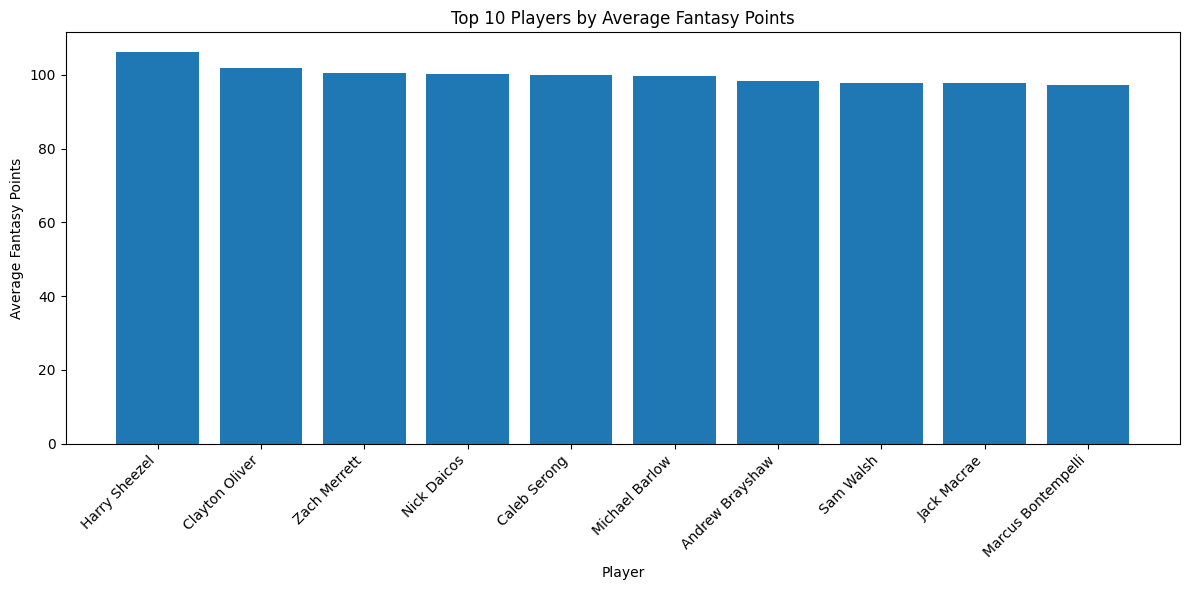

In [10]:
top_players = (
    df_clean.groupby('player_name')['avg_fantasy_points']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

plt.bar(top_players.index, top_players.values)

plt.title('Top 10 Players by Average Fantasy Points')
plt.xlabel('Player')
plt.ylabel('Average Fantasy Points')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

What this tells us: This chart compares the top 10 players and shows which players have the highest average fantasy performance.

**HISTOGRAM**

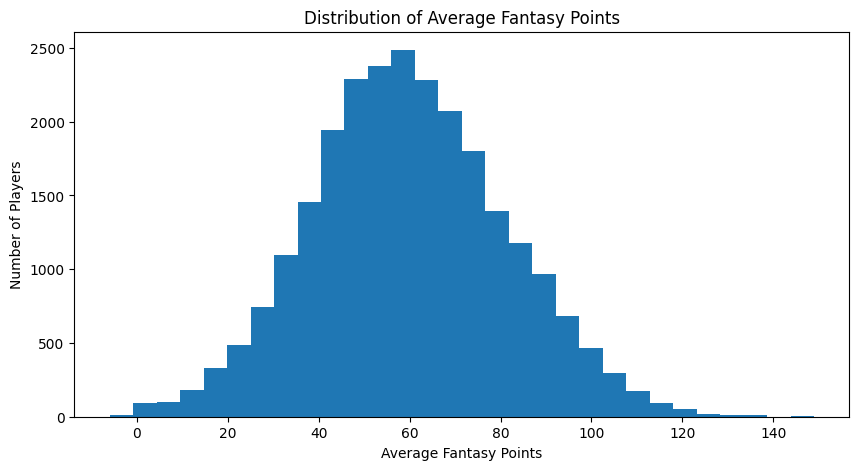

In [11]:
plt.figure(figsize=(10, 5))

plt.hist(
    df_clean['avg_fantasy_points'],
    bins=30
)

plt.title('Distribution of Average Fantasy Points')
plt.xlabel('Average Fantasy Points')
plt.ylabel('Number of Players')

plt.show()

What this tells us: This chart shows how average fantasy points are distributed among the players.

**BOXPLOT**

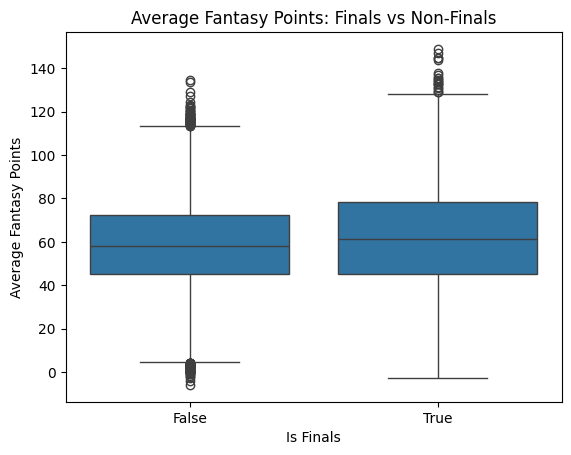

In [13]:
sns.boxplot(
    data=df_clean,
    x='is_finals',
    y='avg_fantasy_points'
)

plt.title('Average Fantasy Points: Finals vs Non-Finals')
plt.xlabel('Is Finals')
plt.ylabel('Average Fantasy Points')

plt.show()

What this tells us: This chart compares the distribution and variation of players' average fantasy points in finals and non-finals games.

**SCATTER PLOT**

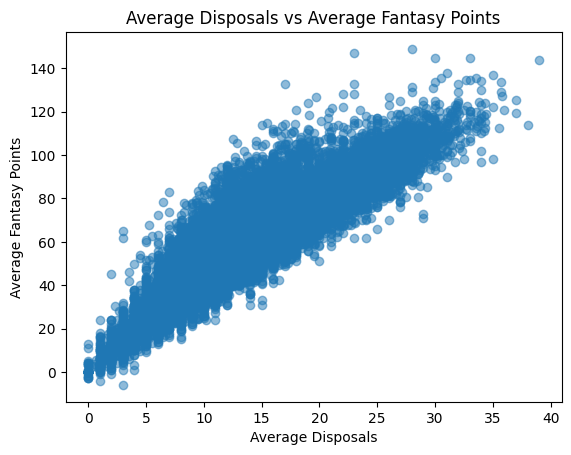

In [17]:
plt.scatter(
    df_clean['avg_disposals'],
    df_clean['avg_fantasy_points'],
    alpha=0.5
)

plt.title('Average Disposals vs Average Fantasy Points')
plt.xlabel('Average Disposals')
plt.ylabel('Average Fantasy Points')

plt.show()

What this tells us: This chart shows the relationship between players' average disposals and their average fantasy points.

**HEATMAP**

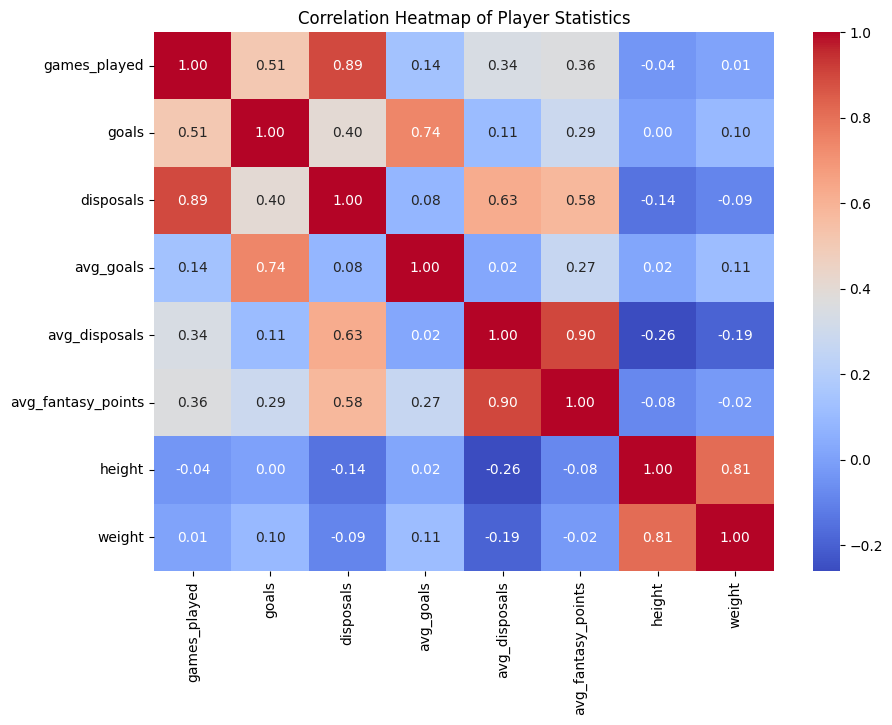

In [18]:
correlation_columns = [
    'games_played',
    'goals',
    'disposals',
    'avg_goals',
    'avg_disposals',
    'avg_fantasy_points',
    'height',
    'weight'
]

correlation_matrix = df_clean[correlation_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap of Player Statistics')

plt.show()

What this tells us: This heatmap shows how strongly different player statistics are related to each other.